In [42]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [5]:
df = pd.read_csv(r"C:\Users\Danie\Documents\DA\Proyectos\Amazon\amazon_sales_dataset.csv")

In [9]:
df.head(10)


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
5,6,2023-12-02,1777,Sports,385.17,30,3,Asia,Wallet,3.8,489,269.62,808.86
6,7,2022-01-21,4068,Books,15.78,0,5,Asia,UPI,1.6,415,15.78,78.90
7,8,2023-09-07,3537,Fashion,111.59,30,4,Middle East,UPI,3.4,143,78.11,312.44
8,9,2022-05-02,3262,Books,373.62,0,4,Asia,Wallet,2.8,497,373.62,1494.48
9,10,2023-04-12,4174,Sports,134.81,15,2,Middle East,Cash on Delivery,2.0,25,114.59,229.18


In [15]:
df.dtypes

order_id                     int64
order_date          datetime64[us]
product_id                   int64
product_category               str
price                      float64
discount_percent             int64
quantity_sold                int64
customer_region                str
payment_method                 str
rating                     float64
review_count                 int64
discounted_price           float64
total_revenue              float64
dtype: object

In [14]:
# Cambio tipo a Fechas
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

In [18]:
#Verificar valores invalidos
df[df['price'] <= 0]
df[df['quantity_sold'] <= 0]
df[df['total_revenue'] <= 0]

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue


In [20]:
#Ver si hay duplicados
dup_order = df[df.duplicated(subset=['order_id'], keep=False)]
print(dup_order)

Empty DataFrame
Columns: [order_id, order_date, product_id, product_category, price, discount_percent, quantity_sold, customer_region, payment_method, rating, review_count, discounted_price, total_revenue]
Index: []


In [22]:
num_duplicados_order = df.duplicated(subset=['order_id']).sum()

print(f"Duplicados en order_id: {num_duplicados_order}")

Duplicados en order_id: 0


In [46]:
# exportar datasets
df.to_csv(r"C:\Users\Danie\Documents\DA\Proyectos\Amazon\df_clean.csv",index=False)

In [47]:
print(os.path.exists("df_clean.csv"))

True


In [24]:
# Analizar el negocio

In [26]:
Ingreso_Total = df['total_revenue'].sum()
print(f"Ingreso Total: {Ingreso_Total}")

Ingreso Total: 32866573.740000002


In [27]:
ticket_promedio = df['total_revenue'].mean()
print(f"Ticket Promedio: {ticket_promedio}")

Ticket Promedio: 657.3314748


In [29]:
cantidad_promedio = df['quantity_sold'].mean()
print(f"Cantidad Promedio por Producto: {cantidad_promedio}")

Cantidad Promedio por Producto: 2.9994


In [30]:
producto_mas_vendido = df.groupby("product_category")['quantity_sold'].sum()
print(f"Categoria más vendida: {producto_mas_vendido .idxmax()}")
print(f"Unidades vendidas: {producto_mas_vendido .max()}")

Categoria más vendida: Beauty
Unidades vendidas: 25422


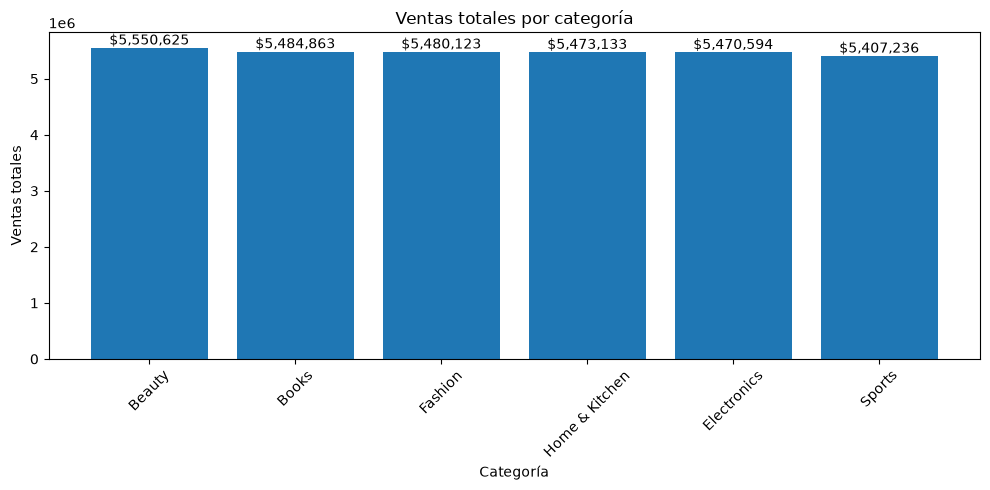

In [39]:
ventas_categoria = (
    df.groupby("product_category")["total_revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

barras = plt.bar(
    ventas_categoria.index,
    ventas_categoria.values
)
plt.title("Ventas totales por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ventas totales")
plt.xticks(rotation=45)

for barra in barras:
    valor = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor,
        f"${valor:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()